# LCEL(LangChain Expression Language)
https://reference.langchain.com/python/langchain_core/runnables/

https://reference.langchain.com/python/langchain_core/runnables/?h=runnablelambd#langchain_core.runnables.base.RunnableLambda
  
- LCEL(LangChain Expression Language)은 LangChain에서 체인을 선언적으로 구성할 수 있게 해주는 도메인 특화 언어다.  
- `|` 연산자를 사용해 프롬프트, 모델, 파서 등을 파이프라인처럼 연결한다.

**주요 특징**

- **선언적 문법**: Unix 파이프처럼 `chain = prompt | model | parser` 형태로 직관적이다.  
- **모듈성·유연성**: 프롬프트, LLM, 파서, 검색기, 메모리 등 컴포넌트를 자유롭게 조합할 수 있다.  
- **동기/비동기 지원**: 단일 코드로 동기식·비동기식 실행을 모두 처리할 수 있다.  
- **병렬 처리 최적화**: 병렬 실행 가능한 단계는 자동으로 병렬화해 지연 시간을 줄인다.  
- **고급 기능 기본 제공**:  
  - 스트리밍 출력으로 응답 속도를 향상시킨다.  
  - 실패 시 재시도와 폴백 경로를 설정할 수 있다.  
  - 중간 결과에 접근해 디버깅이나 진행 상황 표시가 가능하다.

**LCEL의 주요 기능**

1. **스트리밍 지원**: 첫 토큰 도달 시간을 단축해 실시간성을 높인다.  
2. **비동기 지원**: asyncio 환경 등 다양한 실행 환경을 동일 코드로 지원한다.  
3. **병렬 실행 최적화**: 병렬화 가능한 단계는 자동으로 분리해 동시에 실행한다.  
4. **재시도·폴백 구성**: 오류 발생 시 지정 횟수만큼 재시도하거나 대체 경로를 실행한다.  
5. **중간 결과 접근**: 최종 출력 이전에 각 단계의 출력을 확인할 수 있다.

**기본 구성 요소**

- **Runnable**: LCEL의 모든 컴포넌트가 상속하는 기본 클래스다.  
- **Chain**: 여러 Runnable을 순차적으로 실행한다.  
- **RunnableMap**: 여러 Runnable을 병렬로 실행한다.  
- **RunnableSequence**: Runnable들의 시퀀스를 정의한다.  
- **RunnableLambda**: 파이썬 함수를 래핑해 Runnable로 만든다.

흐름(한 줄 요약)

client 요청 → (백엔드가 작업 ID 생성) → 해당 ID 메시지 큐(QUEUE)에 메시지 적재 → Worker가 소비해서 음악 생성 → 결과 파일을 S3 서버 저장공간에 저장 → (ID로 결과 조회/다운로드)

In [1]:
from dotenv import load_dotenv  # .env 파일의 환경변수 로드
import os                       # 환경변수 접근용

load_dotenv()                   # 현재 위치의 .env를 읽어와 환경변수로 등록
os.environ["OPENAI_API_KEY"] = os.getenv("openai_key")  # .env의 openai_key 값을 OPENAI_API_KEY로 등록
os.environ["LANGSMITH_TRACING"] = 'true'                # LangSmith 트레이싱 활성화
os.environ["LANGSMITH_ENDPOINT"] = 'https://api.smith.langchain.com'  # LangSmith API 엔드포인트 설정
os.environ["LANGSMITH_PROJECT"] = 'skn23-langchain'                   # LangSmith 프로젝트명 설정
os.environ["LANGSMITH_API_KEY"] = os.getenv("langsmith_key")          # .env의 langsmith_key 값을 LANGSMITH_API_KEY로 등록

# RunnableLambda

일반 python 함수를lcel 체인에서 사용할 수 있게 wrapping 처리하는 클래스

In [2]:
from langchain_core.runnables import RunnableLambda

runnable = RunnableLambda(lambda x: len(x))
runnable.invoke('플레이데이터 독산 skn-23 화이팅!')

21

In [3]:
# batch : 여러건의 입력을 일괄처리하는 메소드
runnable.batch(['플레이데이터','독산','skn-23','화이팅!'])

[6, 2, 6, 4]

In [4]:
# 섭씨 입력값을 화씨로 변환하는 runnable 생성

def celsius_to_fahrenheit(celsius):
    """섭씨 온도를 화씨 온도로 변환하는 함수"""
    return celsius * 9 / 5 + 32 # 섭씨 -> 화씨 변환 공식

celsius_temps = [0, 25, 100, -10, 37]
runnable = RunnableLambda(celsius_to_fahrenheit)    # 함수를 Runnable로 래핑
runnable.batch(celsius_temps)   # 여러 입력을 한 번에 변환

[32.0, 77.0, 212.0, 14.0, 98.6]

In [6]:
import time                                   # 출력 속도 조절을 위한 time 모듈
def gen(x):                                  # 입력을 받아 제너레이터를 만드는 함수
    for y in x:                              # 입력 문자열을 문자 단위로 순회
        yield y                              # 한 글자씩 스트리밍 출력
        
runnable = RunnableLambda(gen)               # gen 함수를 RunnableLambda로 감싸 Runnable 생성
for chunk in runnable.stream('안녕하세요? 안녕하세요! 안녕하세요~ 안녕하세요? 안녕하세요! 안녕하세요~ 안녕하세요? 안녕하세요! 안녕하세요~ 안녕하세요? 안녕하세요! 안녕하세요~ 안녕하세요? 안녕하세요! 안녕하세요~ '):  # 문자열을 스트리밍으로 처리
    print(chunk, end='', flush=True)         # 줄바꿈 없이 즉시 출력
    time.sleep(0.1)                          # 글자 사이에 0.1초 딜레이


안녕하세요? 안녕하세요! 안녕하세요~ 안녕하세요? 안녕하세요! 안녕하세요~ 안녕하세요? 안녕하세요! 안녕하세요~ 안녕하세요? 안녕하세요! 안녕하세요~ 안녕하세요? 안녕하세요! 안녕하세요~ 

In [7]:
def gen(x):                                  # 입력 문자열을 받아 처리하는 함수
    """입력 문자열을 한 글자(문자)씩 yield하는 제너레이터"""  # 함수 역할 설명
    for y in x:                              # 문자열을 문자 단위로 순회
        yield y                              # 현재 문자를 하나씩 반환
        
gen10 = gen(range(10)) # 0~9를 하나씩 꺼내는 제너레이터 생성
gen10 # 객체 자체 실행 (실행 전/ 소모 전)

<generator object gen at 0x000001A0D5204C70>

In [8]:
for n in gen10:         # gen10에서 값을 하나씩 꺼내며 순회 (꺼낸 값은 다시 사용못함)
    print(n)

0
1
2
3
4
5
6
7
8
9


In [ ]:
next(gen10) # 제너레이터에서 다음 값을 1개 반환(다 꺼내면 StopIteration 발생)

# Runnablesequence

runnable 객체를 순차연결하는

In [10]:
from langchain_core.runnables import RunnableLambda, RunnableSequence

runnable1 = RunnableLambda(lambda x: {'foo':x})  # 입력값에 1 더함

runnable2 = RunnableLambda(lambda x:[x]*3)

chain = RunnableSequence(runnable1, runnable2)

chain.invoke(3)

[{'foo': 3}, {'foo': 3}, {'foo': 3}]

# RunnableParellel

RunnableParallel: 같은 입력을 여러 Runnable에 동시에 보내서, 각 결과를 딕셔너리로 묶어 반환하는 실행기.

In [13]:
from langchain_core.runnables import RunnableParallel, RunnableLambda

runnable1 = RunnableLambda(lambda x: {'foo': x})   # 입력값 x를 받아 {'foo': x} 형태의 딕셔너리로 변환
runnable2 = RunnableLambda(lambda x: [x] * 3)      # 입력값 x를 받아 [x, x, x] 리스트로 변환

chain = RunnableParallel(                          # 같은 입력을 병렬로 각각 실행
    r1=runnable1,                                  # 결과 dict의 키: 'r1'
    r2=runnable2,                                  # 결과 dict의 키: 'r2'
)
chain.invoke(3)                                    # 입력 3 → {'runnable1': {'foo': 3}, 'runnable2': [3, 3, 3]}


{'r1': {'foo': 3}, 'r2': [3, 3, 3]}

사용자가 지정한 주제 (topic)에 대해서 삼행시, 농담, 시를 각각 생성하여 하나의 응답을 작성한다.

In [ ]:
from langchain_core.prompts import PromptTemplate
from langchain.chat_models import init_chat_model
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableParallel, RunnableLambda

llm = init_chat_model("openai:gpt-4.1-mini")
output_parser = StrOutputParser()

acrostic_poem_prompt = PromptTemplate.from_template(
    "당신의 20년 경력의 n행시 고수입니다. 다음 주제로 n행시를 지어주세요. \n\n주제:{topic}"    
)
acrostic_poem_chain = acrostic_poem_prompt | llm | output_parser

joke_poem_prompt = PromptTemplate.from_template(
    "당신의 20년 경력의 농담 고수입니다. 다음 주제로 허를 찌르는 농담을 하나 해주세요 \n\n주제:{topic}"    
)
joke_chain = joke_poem_prompt | llm | output_parser

apoem_prompt = PromptTemplate.from_template(
    "당신의 20년 경력의 시인입니다. 다음 주제로 감성적인 시를 지어주세요 \n\n주제:{topic}"    
)
poem_chain = apoem_prompt | llm | output_parser

chain = RunnableParallel(
    acrostic_poem = acrostic_poem_chain,
    joke = joke_chain,
    poem = poem_chain    
)

def combine_result(input_dict:dict) -> str:
    """병렬 결과(n행시/농담/시)를 한 문자열로 합쳐 반환한다."""
    acrostic_poem = input_dict['acrostic_poem']
    joke = input_dict['joke']
    poem = input_dict['poem']
    return f""" 
        n행시:
        {acrostic_poem}

        농담:
        {joke}

        시:
        {poem}
    """

chain = chain | RunnableLambda(combine_result)
print(chain.invoke({'topic' : '아이스크림'}))

 
n행시:
아: 아직도 달콤한 그 맛이  
이: 이 여름을 시원하게 해줘  
스: 스르르 녹아드는 행복 한 입  
크: 크림처럼 부드러운 그 느낌  
림: 림없이 퍼지는 즐거움, 아이스크림!

농담:
아이스크림 좋아하나요?  
아이스크림이 너무 달아서 감정을 얼릴 것 같아요.  
하지만 걱정 마세요, 녹으면 다 사라집니다!

시:
아이스크림

여름 햇살 속, 살며시 녹아내리는  
하얀 달의 조각처럼,  
손끝에 닿는 순간  
기쁨이 설레임으로 피어나네.  

차가운 그 속에 담긴  
추억의 맛, 달콤한 위로,  
아이처럼 순수한 눈망울에  
녹아내리는 작은 행복의 소리.  

잠시 머무는 여름의 꿈,  
아이스크림 한 스푼에  
바람이 실은 노래를 담아  
우리 마음을 살며시 적신다.



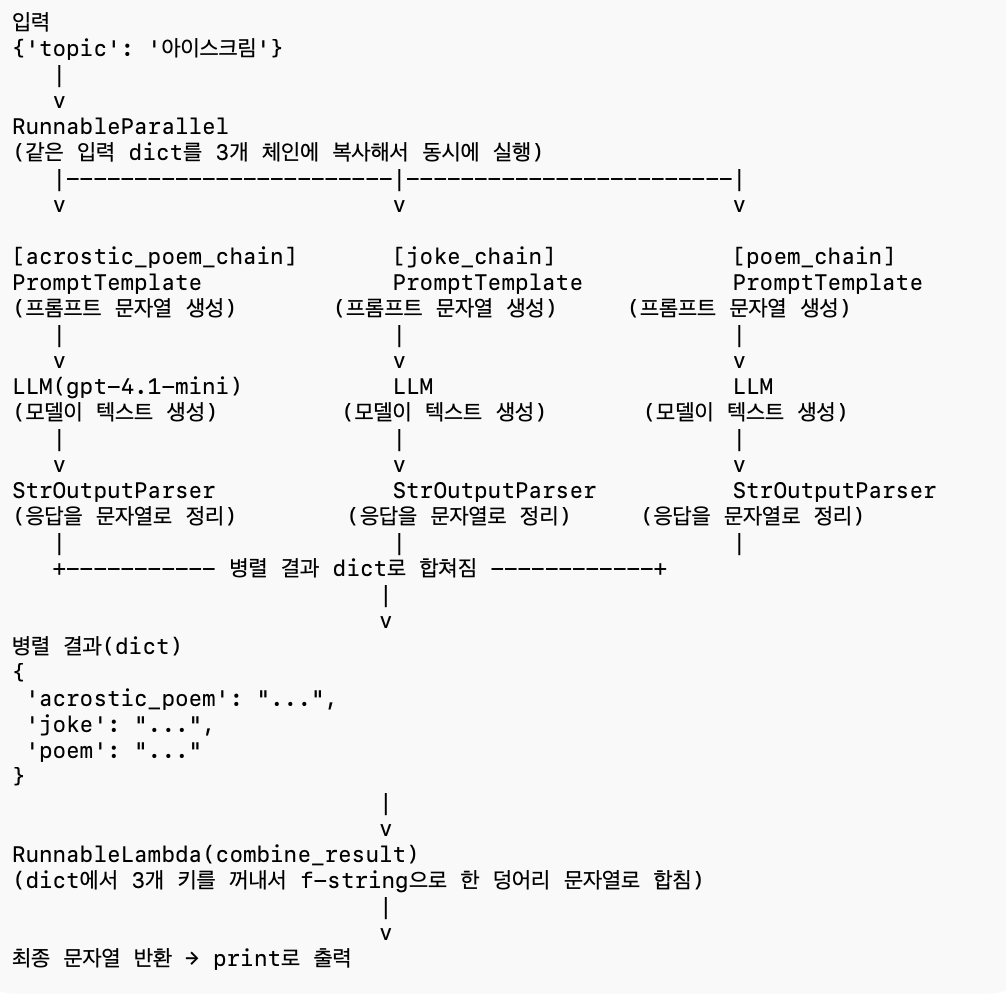

# RunnablePassThought

    - 사용자의입력값을 그대로 전달
    - 입력 dict를 확장

In [18]:
from langchain_core.runnables import RunnablePassthrough

llm = init_chat_model('openai:gpt-4.1-mini')
output_parser = StrOutputParser()

prompt = PromptTemplate.from_template(
    '당신은 창의적인 n행시 고수입니다. 다음주제로 n행시를 지어주세요.\n\n주제:{topic}'
)

chain=(
    {'topic': RunnablePassthrough()}    # 입력(문자열)을 그대로 받아 {'topic': 입력}으로 매핑
    | prompt | llm | output_parser
)

chain.invoke('텀블러')

'텀블러로 지켜요,  \n물 한 방울도 소중하니까,  \n러블리한 습관 하나,  \n깨끗한 지구를 위한 작은 시작!'

In [20]:
from langchain_core.runnables import RunnablePassthrough

prompt = PromptTemplate.from_template("""
    당신은 창의적인{n}행시 고수입니다. 다음 주제로 {n}행시를 지어주세요.                                      
    
    # 주제:
    {topic}
    
    # 출력형식:
    ===== <주제><n>행시 =====
    <n행시 작성>
""")

chain = (
    {'topic':RunnablePassthrough()}
    | RunnablePassthrough.assign(
        n=lambda x: len(x['topic'])
    )
    | prompt
    | llm
    | output_parser
)

chain.invoke('쿠팡정보유출또했대')

'===== 쿠팡정보유출또했대 9행시 =====  \n쿠: 쿠키 한 조각처럼 소중한 개인정보  \n팡: 팡 터지는 소식에 모두가 놀라네  \n정: 정말 또다시 반복된 그 실수  \n보: 보호받아야 할 우리의 데이터인데  \n유: 유출되니 마음 한구석이 시려와  \n출: 출근길 뉴스부터 뒤숭숭해지고  \n또: 또 이런 일이 생기지 않길 바라며  \n했: 했던 약속, 다시 한번 점검해야지  \n대: 대책 마련에 모두가 힘을 모아야 해!'